# 🏠 Predicción del precio de viviendas — Preparación de datos

Este proyecto se centra en la construcción de un dataset limpio y consistente para la predicción de precios de viviendas a partir de datos estructurados.

Objetivos de este notebook:
- Limpieza y preprocesado del dataset original
- Tratamiento de valores nulos con criterios basados en el dominio
- Codificación adecuada de variables categóricas
- Generación de un dataset listo para modelado

Fuente de datos: Kaggle — House Prices: Advanced Regression Techniques

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

## Carga de datos

Se carga el dataset tratando los valores `NA` como datos faltantes.

In [2]:
df = pd.read_csv("data/houses.csv", index_col=0, na_values="NA")

df.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
910,60,RL,149.0,12589,Pave,NaN,IR2,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,174000
1188,20,RL,89.0,12461,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,GdPrv,NaN,0,7,2006,WD,Normal,262000
218,70,RM,57.0,9906,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,WD,Family,107000
444,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2007,New,Partial,172500
1389,20,RL,42.0,14892,Pave,NaN,IR1,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,377500


## Clasificación de variables

Las variables se agrupan en tres tipos:
- Numéricas
- Categóricas nominales
- Categóricas ordinales

Esta separación permite aplicar estrategias de transformación adecuadas en cada caso.

## Tratamiento de valores nulos

Los valores faltantes se tratan en función del tipo de variable:

- **Ordinales** → se asigna la categoría más baja
- **Categóricas nominales** → se asigna "None"
- **Numéricas** → imputación basada en el significado de la variable

### Variables ordinales

Las variables ordinales se transforman utilizando mappings explícitos que preservan el orden semántico.

In [3]:
ordinal_mappings = {
    'LotShape': {'IR3':1,'IR2':2,'IR1':3,'Reg':4},
    'Utilities': {'ELO':1,'NoSeWa':2,'NoSewr':3,'AllPub':4},
    'LandSlope': {'Gtl':1,'Mod':2,'Sev':3},
    'ExterQual': {'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5},
    'Fence': {'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4}
}

ordinal = list(ordinal_mappings.keys())

df = df.replace(ordinal_mappings)
df[ordinal] = df[ordinal].fillna(0)

### Variables numéricas

Se aplican distintas estrategias:

- `LotFrontage` → mediana (variable continua)
- `GarageYrBlt` → valor mínimo (proxy de ausencia)
- `MasVnrArea` → 0 (ausencia de mampostería)

In [4]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].min())

### Variables categóricas

In [5]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns

df[categorical_cols] = df[categorical_cols].astype("string").fillna("None")

## Distribución de la variable objetivo

La variable `SalePrice` presenta asimetría positiva (sesgo a la derecha) y presencia de valores extremos.

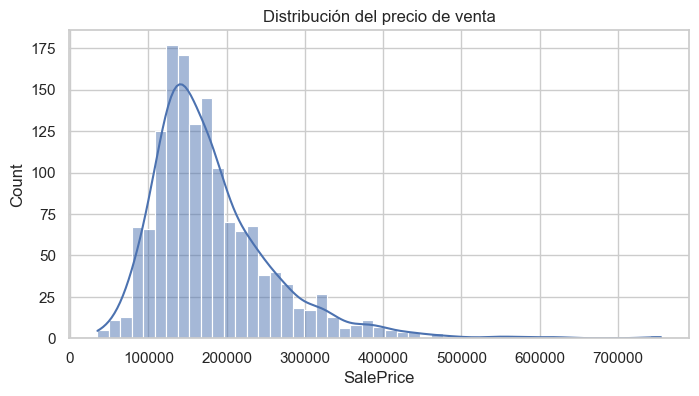

In [6]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribución del precio de venta")
plt.show()

## Análisis de correlación

Se calcula la correlación únicamente sobre variables numéricas para evitar errores derivados de variables categóricas.

In [7]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()['SalePrice'].abs().sort_values(ascending=False)

relevant_features = corr[corr > 0.5].index[1:].tolist()

relevant_features

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt',
 'GarageYrBlt',
 'YearRemodAdd']

## Detección de variables categóricas

Se utilizan tipos modernos de pandas (`string` y `category`) para asegurar compatibilidad futura con nuevas versiones de la librería.

In [8]:
encoded = pd.get_dummies(df[categorical_cols])

corr_cat = pd.concat([encoded, df['SalePrice']], axis=1).corr()['SalePrice']

top_cat = corr_cat.abs().sort_values(ascending=False)[1:20]

top_cat

ExterQual_3              0.589044
BsmtQual_Ex              0.553105
KitchenQual_TA           0.519298
KitchenQual_Ex           0.504094
Foundation_PConc         0.497734
FireplaceQu_None         0.471908
ExterQual_4              0.452466
BsmtQual_TA              0.452394
ExterQual_5              0.451164
BsmtFinType1_GLQ         0.434597
HeatingQC_Ex             0.434543
GarageFinish_Fin         0.419678
GarageFinish_Unf         0.410608
Neighborhood_NridgHt     0.402149
MasVnrType_None          0.367456
SaleType_New             0.357509
GarageType_Detchd        0.354141
SaleCondition_Partial    0.352060
Foundation_CBlock        0.343263
Name: SalePrice, dtype: float64

## Dataset final

Se construye un dataset final combinando variables numéricas, ordinales y categóricas detectadas dinámicamente a partir del estado actual del dataset.

In [9]:
final_df = pd.concat(
    [df.select_dtypes(include=[np.number]), encoded],
    axis=1
)

final_df.to_csv("data/houses_prep.csv", index=False)